[Video de apoyo a la lectura interactiva de este primer cuaderno]()

# Working with Time Series Data in Python

## What is Time Series Data?  



**Time series data** refers to a sequence of data points collected or recorded over a period of time, typically at regular intervals. Each data point in a time series is associated with a specific timestamp, allowing the analysis of trends, patterns, and behaviors over time.



Key characteristics of time series data include:

1. **Temporal Order:** The data points are ordered chronologically, with a clear time sequence indicating when each observation occurred.



2. **Equally Spaced Intervals (Regular Time Intervals):** In many cases, the time intervals between consecutive data points are equally spaced, although irregular time series (with uneven intervals) also exist.



3. **Dependence on Time:** Time series data often exhibits temporal dependencies, meaning that the value of a data point is influenced by or depends on its previous values.



4. **Trends and Seasonality:** Time series data may contain trends, representing long-term movements, and seasonality, indicating repeating patterns over shorter time intervals (e.g., daily, weekly, or yearly patterns).



Common examples of time series data include stock prices, weather observations, economic indicators, sales figures, and sensor readings. Analyzing time series data involves techniques such as smoothing, decomposition, forecasting, and identifying patterns or anomalies. Time series analysis is widely used in various fields, including finance, economics, environmental science, and engineering.

# Ejemplo de serie de tiempo en valores de acciones de la empresa IBM

Lo siento, pero no tengo la capacidad de acceder a enlaces externos, incluyendo el que proporcionaste. Sin embargo, puedo explicarte qué es probable que contenga un conjunto de datos de series temporales diarias para el símbolo "IBM" descargado desde Alpha Vantage, basándome en la información general sobre la API de Alpha Vantage.



En general, la función `TIME_SERIES_DAILY` de Alpha Vantage proporciona datos históricos diarios para una acción o símbolo específico, como "IBM" en este caso. Los conjuntos de datos de series temporales diarias suelen incluir información como la fecha, el precio de apertura, el precio más alto, el precio más bajo y el precio de cierre de la acción para cada día.



Aquí hay una descripción general de los posibles campos que podrías encontrar en un conjunto de datos de series temporales diarias:

1. **Fecha (Date):** La fecha en la que se registraron los datos.
2. **Precio de Apertura (Open):** El precio al que se abrió la acción al inicio del día.
3. **Precio Máximo (High):** El precio más alto alcanzado durante el día.
4. **Precio Mínimo (Low):** El precio más bajo alcanzado durante el día.
5. **Precio de Cierre (Close):** El precio al que se cerró la acción al final del día.
6. **Volumen (Volume):** El número total de acciones negociadas durante el día.



Estos datos se pueden utilizar para realizar análisis y estudios de tendencias, calcular métricas financieras y crear visualizaciones para comprender el rendimiento histórico de una acción específica, en este caso, IBM. La información se presenta en un formato de tabla con filas correspondientes a días específicos y columnas correspondientes a los diferentes atributos mencionados anteriormente.

In [5]:
import pandas as pd

df = pd.read_csv("https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=IBM&apikey=demo&datatype=csv")

df.head() 

# https://www.alphavantage.co/

,timestamp,open,high,low,close,volume
0,2024-01-31,187.05,187.6500,183.14,183.66,8876055
1,2024-01-30,187.71,188.6500,186.77,187.87,4575058
2,2024-01-29,187.46,189.4600,186.05,187.14,6107908
3,2024-01-26,191.31,192.3896,186.16,187.42,9895941
4,2024-01-25,184.96,196.9000,184.83,190.43,29596239


In [7]:
#Note que los datos en el atributo timestamp son cadenas de caracteres

type(df.timestamp[0])

str

In [8]:
df['timestamp'] = pd.to_datetime(df.timestamp) # hacer que pandas declare ell atributo timestamp como un dato de tiempo

df.head()

,timestamp,open,high,low,close,volume
0,2024-01-31,187.05,187.6500,183.14,183.66,8876055
1,2024-01-30,187.71,188.6500,186.77,187.87,4575058
2,2024-01-29,187.46,189.4600,186.05,187.14,6107908
3,2024-01-26,191.31,192.3896,186.16,187.42,9895941
4,2024-01-25,184.96,196.9000,184.83,190.43,29596239


In [10]:
type(df['timestamp'][0])

pandas._libs.tslibs.timestamps.Timestamp

In [12]:
df.index = df.timestamp  
# hacer que la familia indexante del dataframe sea el atributo de fecha llamado timestamp
df 

,timestamp,open,high,low,close,volume
timestamp,,,,,,
2024-01-31,2024-01-31,187.05,187.6500,183.14,183.66,8876055
2024-01-30,2024-01-30,187.71,188.6500,186.77,187.87,4575058
2024-01-29,2024-01-29,187.46,189.4600,186.05,187.14,6107908
2024-01-26,2024-01-26,191.31,192.3896,186.16,187.42,9895941
2024-01-25,2024-01-25,184.96,196.9000,184.83,190.43,29596239
...,...,...,...,...,...,...
2023-09-14,2023-09-14,147.38,147.7300,146.48,147.35,2723200
2023-09-13,2023-09-13,145.95,146.9800,145.92,146.55,2627999
2023-09-12,2023-09-12,147.92,148.0000,145.80,146.30,4457695


In [13]:
df.drop(['timestamp'], axis = 1, inplace=True)
df 

,open,high,low,close,volume
timestamp,,,,,
2024-01-31,187.05,187.6500,183.14,183.66,8876055
2024-01-30,187.71,188.6500,186.77,187.87,4575058
2024-01-29,187.46,189.4600,186.05,187.14,6107908
2024-01-26,191.31,192.3896,186.16,187.42,9895941
2024-01-25,184.96,196.9000,184.83,190.43,29596239
...,...,...,...,...,...
2023-09-14,147.38,147.7300,146.48,147.35,2723200
2023-09-13,145.95,146.9800,145.92,146.55,2627999
2023-09-12,147.92,148.0000,145.80,146.30,4457695


# Visualizar uno de los atributos del dataframe

<Axes: xlabel='timestamp'>

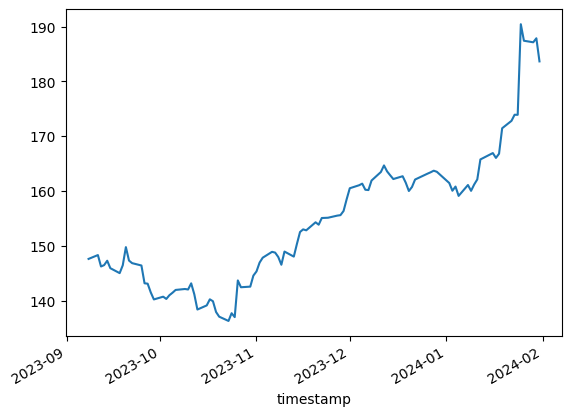

In [14]:

df['close'].plot()

### We can do this all in one with...

In [22]:
df = pd.read_csv("https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=IBM&apikey=demo&datatype=csv" \
                       , parse_dates=['timestamp'], index_col = 'timestamp')

df.head()

,open,high,low,close,volume
timestamp,,,,,
2024-01-31,187.05,187.6500,183.14,183.66,8876055
2024-01-30,187.71,188.6500,186.77,187.87,4575058
2024-01-29,187.46,189.4600,186.05,187.14,6107908
2024-01-26,191.31,192.3896,186.16,187.42,9895941
2024-01-25,184.96,196.9000,184.83,190.43,29596239


[]()

# Working With Time Series Data

## Time-based indexing and slicing

In [34]:
stamp = df.index[0]
stamp 

Timestamp('2024-01-31 00:00:00')

In [35]:
df.loc['2024-01-30']

open          187.71
high          188.65
low           186.77
close         187.87
volume    4575058.00
Name: 2024-01-30 00:00:00, dtype: float64

In [48]:
# We can slice the dataframe

from datetime import datetime 

sample = df.low[datetime(2024,1,20):datetime(2024,1,31)]

sample.head()

Series([], Name: low, dtype: float64)

## What is Stationarity? Why does it matter?

A **stationary** time series is one whose statistical properties, such as mean, variance, and autocorrelation, do not change over time.

- **Constant Mean:** The mean of the series should not be a function of time.

- **Constant Variance:** The variance of the series should not be a function of time. This property is known as homoscedasticity

- **Constant Covariance:** The covariance of the i-th term and the (i+m)-th term should not be a function of time.

### The tale of two datasets

<Axes: title={'center': 'HR Data'}>

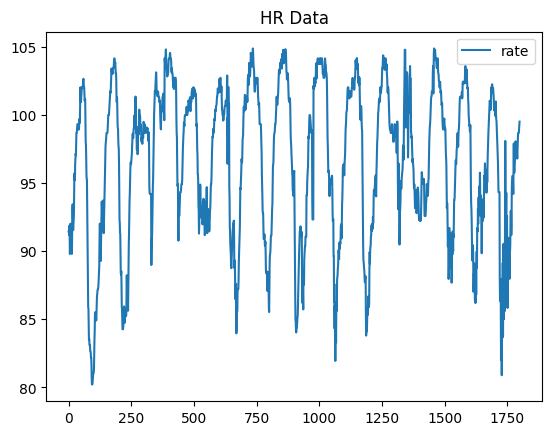

In [3]:
### Heart Rate data


hr = pd.read_csv("https://raw.githubusercontent.com/alyssaq/python-data-science-intro/master/datasets/heart-rate-time-series.csv", header=None)
hr.columns = ['rate']

# Plot our Heart Rate Data
hr.plot(title='HR Data')

### The tale of two datasets

In [ ]:
df['close'].plot(title='Stock Data')

## Tests for Stationarity

### Augmented Dickey-Fuller (ADF) Test

The ADF test is one of the most popular statistical tests to check the stationarity of a time series. The null hypothesis of the ADF test is that the time series is non-stationary due to the presence of a unit root.

$ 
\Delta Y_t = \alpha + \beta t + \gamma Y_{t-1} + \delta_1 \Delta Y_{t-1} + \ldots + \delta_{p-1} \Delta Y_{t-p+1} + \epsilon_t
$

Where:
- $\Delta Y_t$ is the difference series
- $\alpha$, $\beta$, and $\gamma$ are coefficients
- $p$ is the number of lags
- $\epsilon_t$ is the error term



### Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test

The KPSS test is another popular test for stationarity, where the null hypothesis is that the data is stationary around a deterministic trend.

$
Y_t = \alpha + \beta t + \rho Y_{t-1} + \epsilon_t
$

Where:
- $Y_t$ is the time series
- $\alpha$ and $\beta$ are coefficients
- $\rho$ is the autoregressive parameter
- $\epsilon_t$ is the error term

## The tests in action

### The ADF test

In [ ]:
from statsmodels.tsa.stattools import adfuller

result_adf_stock = adfuller(df['close'])
result_adf_hr = adfuller(hr)

print(f'ADF Statistic Stock: {result_adf_stock[0]}')
print(f'p-value: {result_adf_stock[1]}')
print('Critical Values:')
for key, value in result_adf_stock[4].items():
    print(f'\t{key}: {value}')

print("---------------------------")
    
print(f'ADF Statistic HR: {result_adf_hr[0]}')
print(f'p-value: {result_adf_hr[1]}')
print('Critical Values:')
for key, value in result_adf_hr[4].items():
    print(f'\t{key}: {value}') 

## The tests in action

### The KPSS Test

In [ ]:
from statsmodels.tsa.stattools import kpss

# Perform KPSS test
result_adf_stock = kpss(df['close'], nlags="auto")
result_adf_hr = kpss(hr, nlags="auto")


print(f'KPSS Statistic: {result_adf_stock[0]}')
print(f'p-value: {result_adf_stock[1]}')
print('Critical Values:')
for key, value in result_adf_stock[3].items():
    print(f'\t{key}: {value}')
    
print("---------------------------")

print(f'KPSS Statistic: {result_adf_hr[0]}')
print(f'p-value: {result_adf_hr[1]}')
print('Critical Values:')
for key, value in result_adf_hr[3].items():
    print(f'\t{key}: {value}')

## How do we fix TS data that is not Stationarity?

## Differencing

Differencing is a technique used to make a non-stationary time series stationary. It involves transforming the series by computing the differences between consecutive observations.

### First Order Differencing

The first difference is given by the following equation:

$ 
\Delta Y_t = Y_t - Y_{t-1}
$


In [ ]:
df = df.sort_index()
new_station_data = df['close'].diff()
new_station_data = new_station_data.dropna()
new_station_data.head()

In [ ]:
result_adf_stock = adfuller(new_station_data)
result_kpss_stock = kpss(new_station_data, nlags="auto")

print(f'ADF Statistic Stock: {result_adf_stock[0]}')
print(f'p-value: {result_adf_stock[1]}')
print('Critical Values:')
for key, value in result_adf_stock[4].items():
    print(f'\t{key}: {value}')
    
print("---------------------------")

print(f'KPSS Statistic: {result_kpss_stock[0]}')
print(f'p-value: {result_kpss_stock[1]}')
print('Critical Values:')
for key, value in result_kpss_stock[3].items():
    print(f'\t{key}: {value}')
    


In [ ]:
new_station_data.plot(title='Stock Data')